Text(0.5, 1.0, 'PCA — red=queenless, blue=queenright')

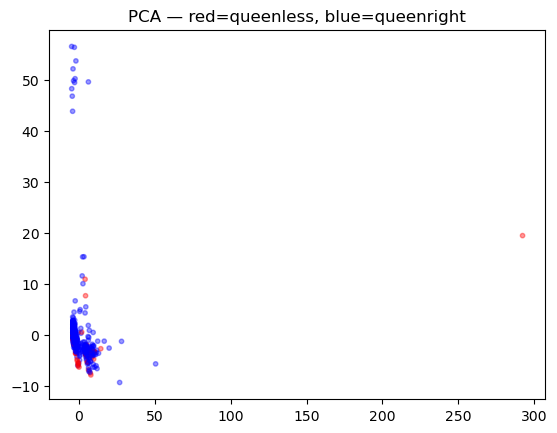

In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot
import paths
import dataframes
all_features = dataframes.from_filepath(paths.all_merged_features_filepath)
all_features = all_features.drop_duplicates(subset=["timestamp", "time_slice", "hive"], keep="first")
all_features =all_features.dropna()
numeric_columns = dataframes.numeric_columns_from_dataframe(all_features)
scaled = StandardScaler().fit_transform(all_features[numeric_columns])
projected = PCA(n_components=2).fit_transform(scaled)

colors = all_features["queenlessness"].map({True: "red", False: "blue"})
matplotlib.pyplot.scatter(projected[:, 0], projected[:, 1], c=colors, alpha=0.4, s=10)
matplotlib.pyplot.title("PCA — red=queenless, blue=queenright")

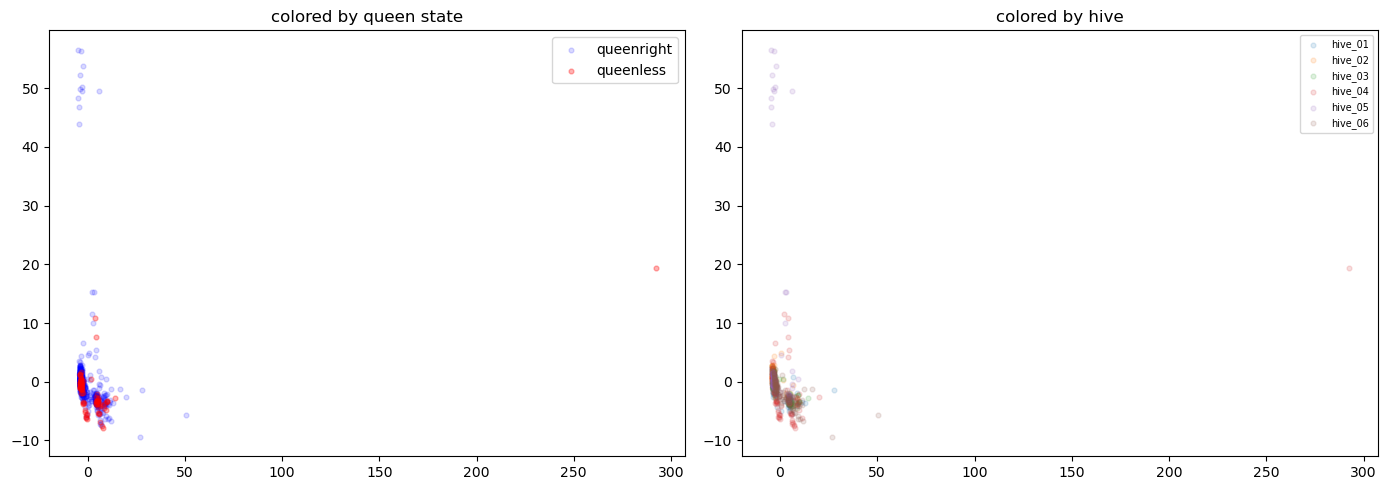

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot

import dataframes

numeric_columns = dataframes.numeric_columns_from_dataframe(all_features)
scaled = StandardScaler().fit_transform(all_features[numeric_columns])
projected = PCA(n_components=2).fit_transform(scaled)

figure, axes = matplotlib.pyplot.subplots(ncols=2, figsize=(14, 5))

queenless_mask = all_features["queenlessness"].values

axes[0].scatter(projected[~queenless_mask, 0], projected[~queenless_mask, 1],
    c="blue", alpha=0.15, s=12, label="queenright")
axes[0].scatter(projected[queenless_mask, 0], projected[queenless_mask, 1],
    c="red", alpha=0.3, s=12, label="queenless")
axes[0].set_title("colored by queen state")
axes[0].legend()

hive_names = all_features["hive"].unique()
for hive_name in sorted(hive_names):
    hive_mask = all_features["hive"].values == hive_name
    axes[1].scatter(projected[hive_mask, 0], projected[hive_mask, 1],
        alpha=0.15, s=12, label=hive_name)
axes[1].set_title("colored by hive")
axes[1].legend(fontsize=7)

figure.tight_layout()

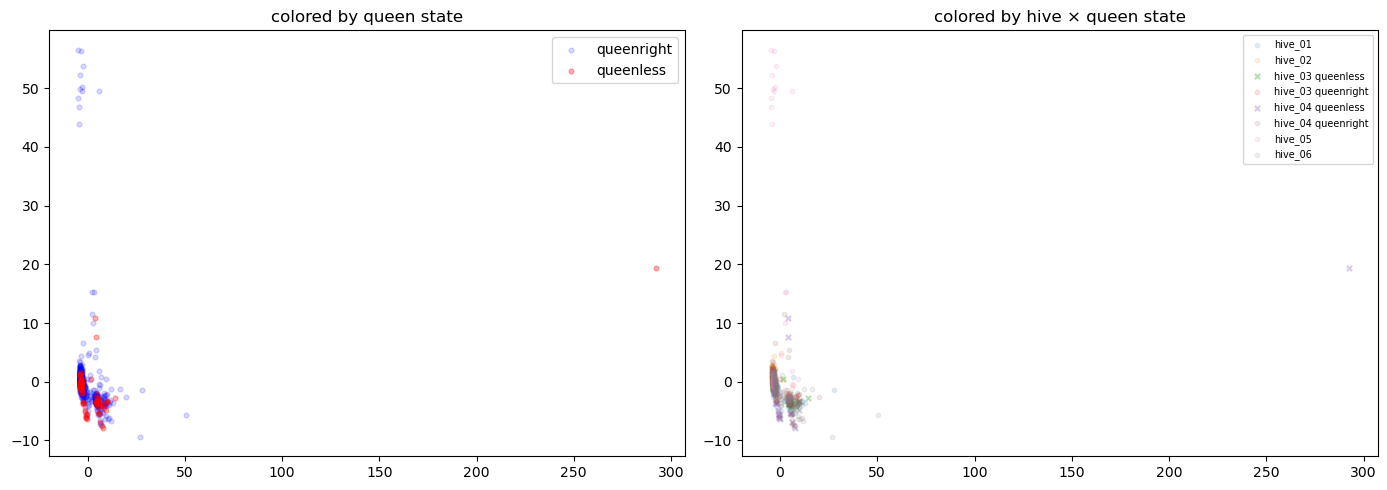

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot

import dataframes

numeric_columns = dataframes.numeric_columns_from_dataframe(all_features)
scaled = StandardScaler().fit_transform(all_features[numeric_columns])
projected = PCA(n_components=2).fit_transform(scaled)

figure, axes = matplotlib.pyplot.subplots(ncols=2, figsize=(14, 5))

queenless_mask = all_features["queenlessness"].values

axes[0].scatter(projected[~queenless_mask, 0], projected[~queenless_mask, 1],
    c="blue", alpha=0.15, s=12, label="queenright")
axes[0].scatter(projected[queenless_mask, 0], projected[queenless_mask, 1],
    c="red", alpha=0.3, s=12, label="queenless")
axes[0].set_title("colored by queen state")
axes[0].legend()

def label_from_row(row):
    match row["hive"], row["queenlessness"]:
        case "hive_03", True:  return "hive_03 queenless"
        case "hive_03", False: return "hive_03 queenright"
        case "hive_04", True:  return "hive_04 queenless"
        case "hive_04", False: return "hive_04 queenright"
        case hive, _:          return hive

labels = all_features.apply(label_from_row, axis=1)

for label in sorted(labels.unique()):
    mask = labels.values == label
    is_queenless = "queenless" in label
    axes[1].scatter(projected[mask, 0], projected[mask, 1],
        alpha=0.35 if is_queenless else 0.12,
        s=14 if is_queenless else 10,
        marker="x" if is_queenless else "o",
        label=label)

axes[1].set_title("colored by hive × queen state")
axes[1].legend(fontsize=7)
figure.tight_layout()

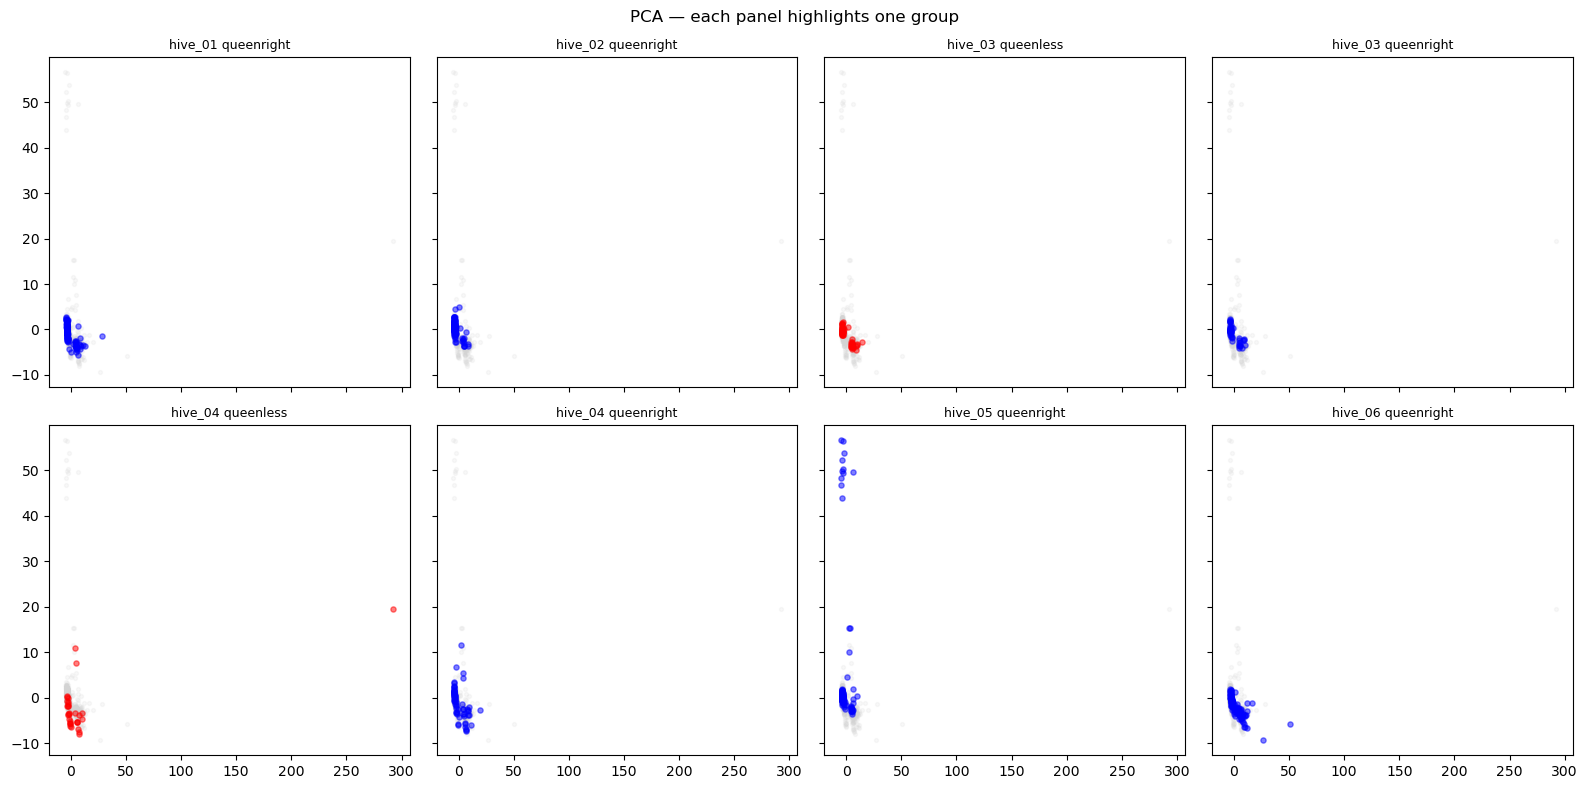

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot

import dataframes

numeric_columns = dataframes.numeric_columns_from_dataframe(all_features)
scaled = StandardScaler().fit_transform(all_features[numeric_columns])
projected = PCA(n_components=2).fit_transform(scaled)

def label_from_row(row):
    match row["hive"], row["queenlessness"]:
        case "hive_03", True:  return "hive_03 queenless"
        case "hive_03", False: return "hive_03 queenright"
        case "hive_04", True:  return "hive_04 queenless"
        case "hive_04", False: return "hive_04 queenright"
        case hive, _:          return f"{hive} queenright"

labels = all_features.apply(label_from_row, axis=1)
unique_labels = sorted(labels.unique())

n_labels = len(unique_labels)
n_columns = 4
n_rows = (n_labels + n_columns - 1) // n_columns

figure, axes = matplotlib.pyplot.subplots(
    nrows=n_rows, ncols=n_columns,
    figsize=(4 * n_columns, 4 * n_rows),
    sharex=True, sharey=True,
)

for axis_index, axis in enumerate(axes.flat):
    if axis_index >= n_labels:
        axis.set_visible(False)
        continue

    highlighted_label = unique_labels[axis_index]
    highlighted_mask = labels.values == highlighted_label

    axis.scatter(
        projected[~highlighted_mask, 0], projected[~highlighted_mask, 1],
        c="lightgrey", alpha=0.15, s=8, zorder=1,
    )
    axis.scatter(
        projected[highlighted_mask, 0], projected[highlighted_mask, 1],
        c="red" if "queenless" in highlighted_label else "blue",
        alpha=0.5, s=14, zorder=2,
    )
    axis.set_title(highlighted_label, fontsize=9)

figure.suptitle("PCA — each panel highlights one group", fontsize=12)
figure.tight_layout()